# The Keyboard Penalty: Device Ubiquity, Keyboarding Coursework Collapse, and Digital Assessment Mode Effects
### A Computational Literature Synthesis, Empirical Reconciliation, and Parameter Sensitivity Analysis
**Computational Sketchbook: Education Policy & Measurement Observatory**  
*Primary Sources: NCES High School Transcript Study (Table 1), NCES School Pulse Panel (2025), Education Week Research Center (2024), NCES 2017 NAEP Mode Evaluation Study (Table 4.1c), IEA ICILS (2018–2023), Backes & Cowan (2019, Economics of Education Review), Gordanier et al. (2023, Education Finance and Policy), Parker (2018, JRBE).*

---

## Executive Summary & Research Scope

Over the past two decades, American elementary and secondary education experienced three simultaneously colliding transformations:
1. **Device Ubiquity**: U.S. public schools expanded individual computer access to **88.0%** of schools by 2024–25 (NCES School Pulse Panel).
2. **Keyboarding Coursework Collapse**: High school graduates earning course credit in keyboarding collapsed from **44.1% in 2000 to 2.5% in 2019** (NCES High School Transcript Study, Table 1)—a **94.3%** structural decline.
3. **Universal Digital Assessment Mandates**: State testing consortia (PARCC, Smarter Balanced) and federal monitoring assessments (NAEP reading and mathematics in 2017) shifted from paper-and-pencil tests (PBA) to digitally based assessments (DBA).

When educational assessments require students to demonstrate academic abilities through digital interfaces, the testing medium itself can introduce **Construct-Irrelevant Variance (CIV)**.

### Calibrated Central Finding
> **Digital administration can affect measured student performance, and the differences appear particularly pronounced on constructed-response items among younger students. The degree to which typing fluency explains those differences remains unresolved.**

### Project Reclassification
This project is a **computational literature synthesis, empirical reconciliation, and parameter sensitivity analysis**. It synthesizes published findings from peer-reviewed journals and official government evaluations, evaluates the sensitivity of hypothesized typing thresholds, and outlines an experimental protocol to isolate the keyboarding mechanism.


## 1. Epistemic Demarcation: Claim 1 vs. Claim 2

To maintain scientific integrity, we draw an absolute boundary between two distinct empirical claims:

| Feature | Claim 1: Interface Penalty Claim | Claim 2: Macro Score Decline Attribution |
| :--- | :--- | :--- |
| **Proposition** | Digital administration can depress student performance, especially on constructed-response items among younger students. | The national decline in standardized test scores over the past decade was caused by declining keyboarding instruction. |
| **Psychometric Status** | **Construct-Irrelevant Difficulty** (Messick 1989; Berninger 1999). | Causal attribution with massive unobserved macro confounders. |
| **Empirical Status** | **Supported by Replicated Evidence**: State transitions (MA $-0.25$ SD ELA, SC panel) and NAEP Table 4.1c ($-6.8$ pp on G4 CR vs. $-3.8$ pp on SR). | **Unsupported**: NAEP 2017+ trends are statistically linked for mode; score declines continued in 2022–2024 within an already digital baseline; typing courses alone (Parker 2018) showed null writing gains. |
| **Research Action** | **Admitted to study**: Reconcile published effect sizes, item-format differences, and parameter sensitivity. | **Quarantined from causal claims**: Rejected as an unsupported causal attribution. |

### The Six-Point Study Admission Gate
1. **Retrieval & Usability**: Underlying administrative and survey records are retrieved and versioned in reproducible tabular datasets.
2. **Fixed Population & Denominator**: Analytical populations are explicitly bounded prior to analysis.
3. **Written Mathematical Model**: The classical test theory error decomposition and parameter sensitivity equations are specified mathematically.
4. **Directional Neutrality**: Null findings (such as selected-response items showing smaller mode differences, or standalone typing courses showing null writing gains) substantively answer the research question without bias.
5. **Audited Sensitivity Check**: Cross-study variation in mode penalties is bounded and contextualized across different jurisdictions and methodologies.
6. **Scholarly & Survey Integrity**: Full transparency regarding NAEP's official decision to suppress the 2017 Writing assessment and the unverified status of questionnaire response frequencies.


## 2. Environment Setup & Data Ingestion

We load the standardized datasets compiled in `data/processed/` and `data/raw/`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "artifacts" / "tables"
FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-09-keyboarding-mode-effects


## 3. The Infrastructure Paradox: Keyboarding Collapse vs. 1:1 Laptop Ubiquity

Over the last 25 years, while public schools achieved nearly universal 1-to-1 computing infrastructure, formal high school coursework in keyboarding virtually disappeared.

We examine **Table 1 from the NCES NAEP High School Transcript Study (HSTS)** alongside verified data from the **NCES School Pulse Panel**.


In [2]:
# Load Audited HSTS Table 1 and School Pulse Data
df_hsts = pd.read_csv(RAW_DIR / "nces_hsts_2019_table1.csv")
df_pulse = pd.read_csv(RAW_DIR / "nces_pulse_device_access.csv")

print("--- NCES High School Transcript Study (Table 1: Keyboarding & Computer Courses) ---")
display(df_hsts)

print()
print("--- NCES School Pulse Panel: Public School 1:1 Device Programs ---")
display(df_pulse)


--- NCES High School Transcript Study (Table 1: Keyboarding & Computer Courses) ---


,course_title,year,pct_graduates,se,stat_diff_from_2019,verification_status
0,Keyboarding,2000,44.1,1.25,True,Verified (HSTS Table 1)
1,Keyboarding,2005,26.6,1.11,True,Verified (HSTS Table 1)
2,Keyboarding,2009,15.0,0.88,True,Verified (HSTS Table 1)
3,Keyboarding,2019,2.5,0.28,False,Verified (HSTS Table 1)
4,Computer Applications,2000,3.1,0.35,True,Verified (HSTS Table 1)
5,Computer Applications,2005,26.8,1.14,True,Verified (HSTS Table 1)
6,Computer Applications,2009,31.4,1.18,True,Verified (HSTS Table 1)
7,Computer Applications,2019,10.4,0.58,False,Verified (HSTS Table 1)
8,Business Computer Applications,2000,6.2,0.54,True,Verified (HSTS Table 1)
9,Business Computer Applications,2005,7.1,0.53,True,Verified (HSTS Table 1)



--- NCES School Pulse Panel: Public School 1:1 Device Programs ---


,survey_program,year,school_year,pct_1to1_devices,reported_metric,comparable_to_pulse,verification_status
0,NCES School Pulse Panel,2021,2021-22,83.0,83% of public schools report 1:1 computing pro...,True,Verified (NCES School Pulse 2022)
1,NCES School Pulse Panel,2024,2024-25,88.0,88% of public schools report 1:1 computing pro...,True,Verified (NCES School Pulse 2025)


In [3]:
# Display Audited Summary Table 1
df_table1 = pd.read_csv(TABLES_DIR / "table1_hsts_course_trends.csv")
display(df_table1)


,indicator,historical_benchmark,recent_benchmark,net_change,verification_status,source_citation
0,High School Graduates Earning Keyboarding Credit,44.1% (2000),2.5% (2019),-41.6 pp (-94.3% rel),Verified (NCES HSTS Table 1),"NCES High School Transcript Study 2019, Table 1"
1,High School Graduates Earning Computer Applica...,3.1% (2000) / 31.4% (2009),10.4% (2019),+7.3 pp from 2000 (-21.0 pp from peak),Verified (NCES HSTS Table 1),"NCES High School Transcript Study 2019, Table 1"
2,High School Graduates Earning Word Processing ...,12.8% (2000),1.2% (2019),-11.6 pp (-90.6% rel),Verified (NCES HSTS Table 1),"NCES High School Transcript Study 2019, Table 1"
3,Public Schools with 1:1 Student Device Programs,"83.0% (2021-22, School Pulse)",88.0% (2024-25),+5.0 pp in School Pulse Panel,Verified (NCES School Pulse 2025),NCES School Pulse Panel (2021-2025)
4,US 8th-Grade Computer & Information Literacy (...,519 pts (2018),482 pts (2023),-37.0 scale pts (-0.37 SD),Verified (IEA ICILS 2018/2023),IEA / NCES ICILS Assessment Reports


### Figure 1 Exhibit: The Divergent Curves
We visualize the divergence between device presence, keyboarding coursework, and digital literacy.


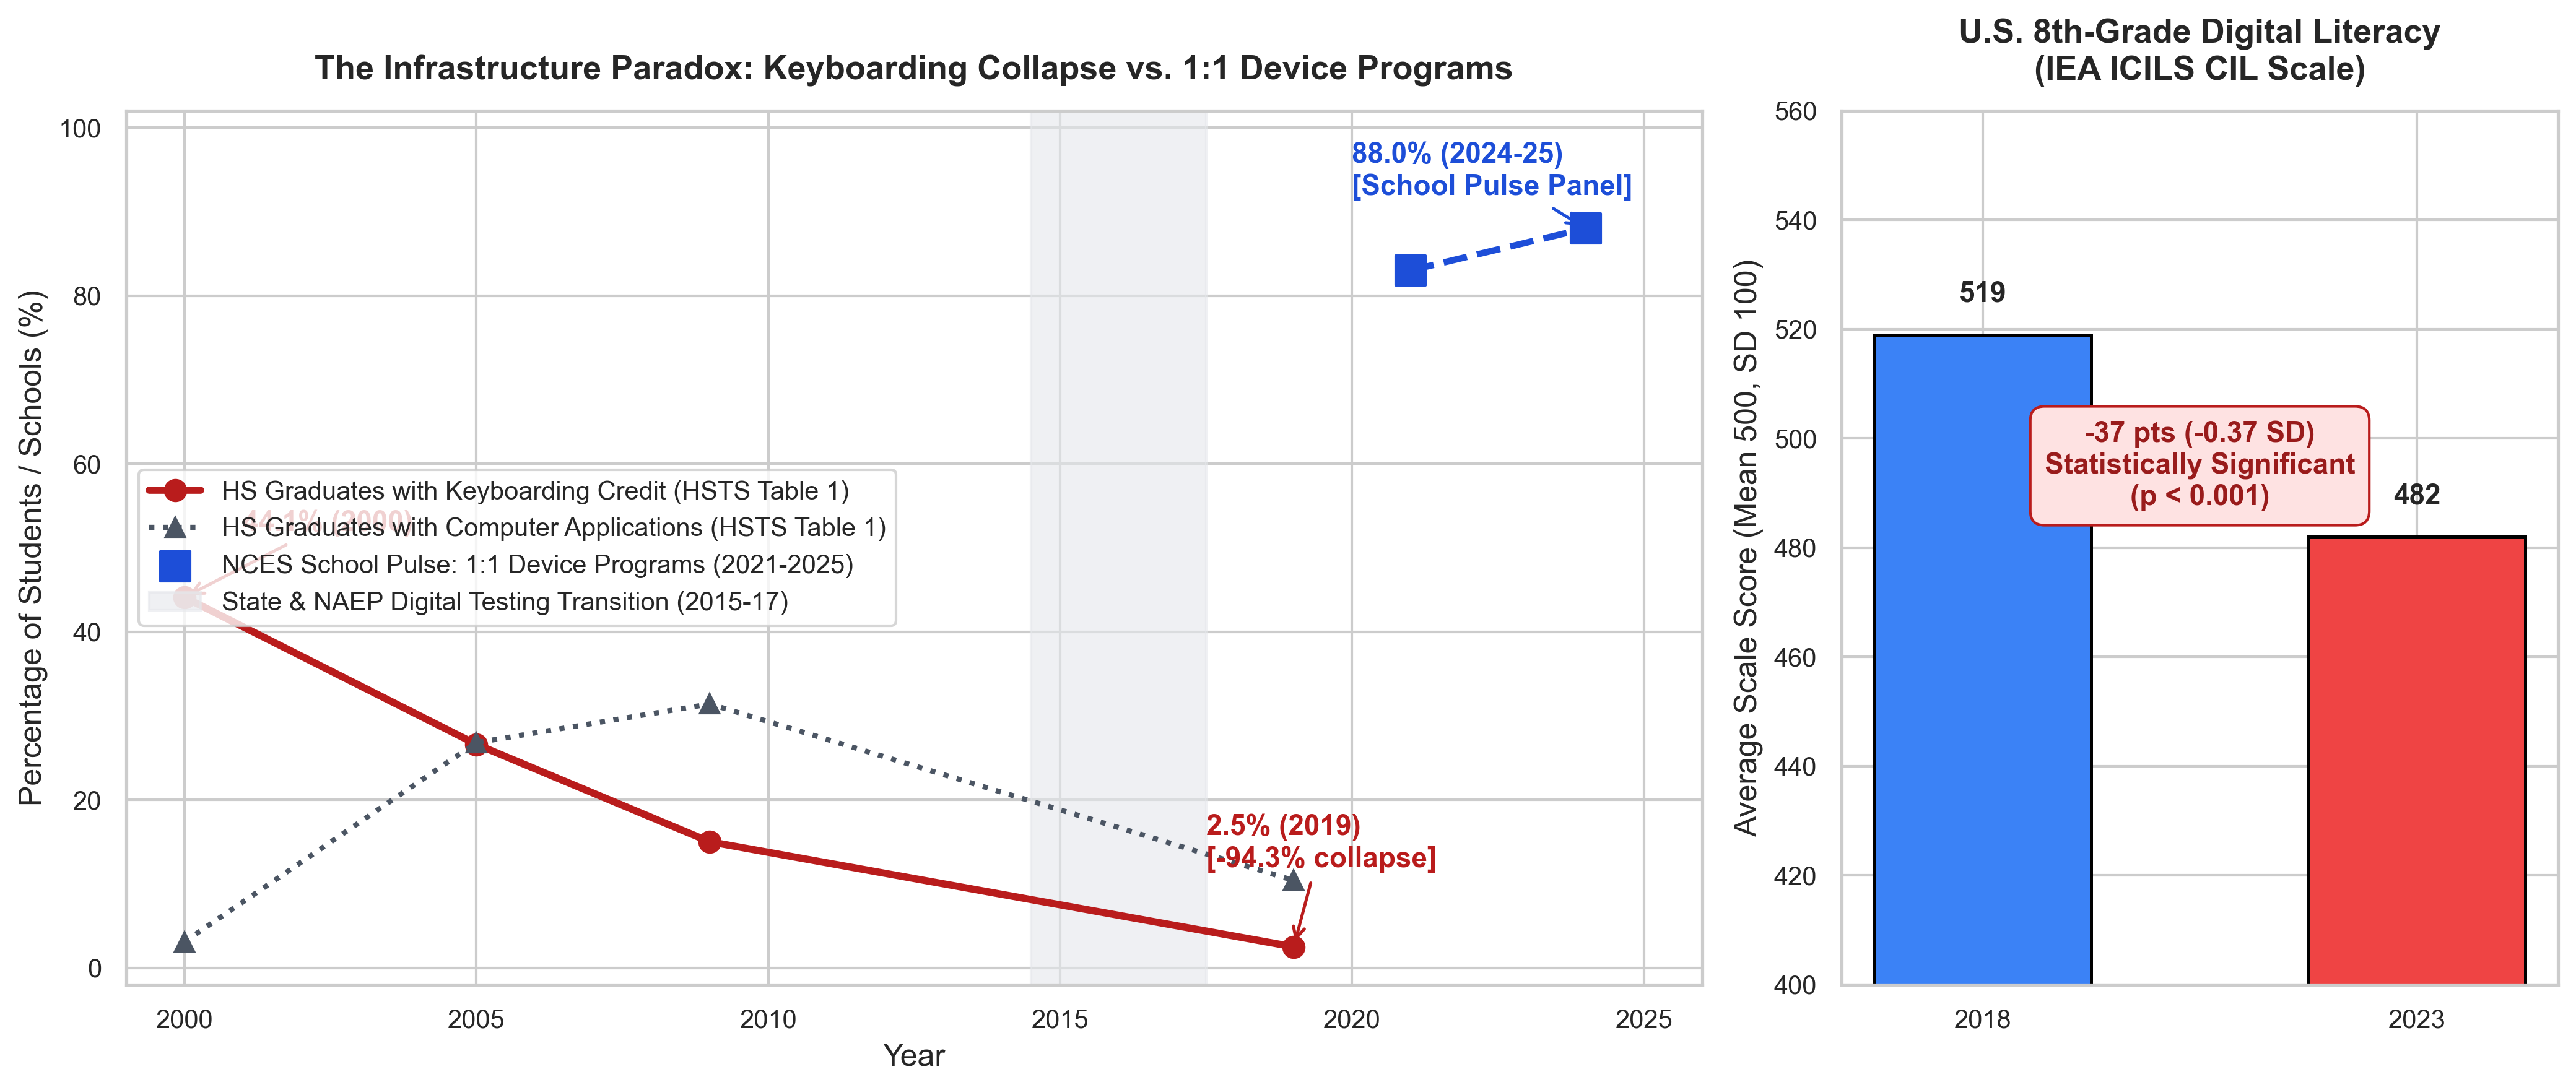

In [4]:
from IPython.display import Image
Image(filename=str(FIG_DIR / "fig1_three_divergent_trends.png"))


## 4. Current Keyboarding Instruction & The Poverty Gradient (EdWeek 2024)

Does the absence of high school keyboarding credits simply mean students learn to type earlier in elementary school?

A nationally representative 2024 survey of $N = 404$ school and district leaders by the **Education Week Research Center** reveals that instruction is fractured and marked by a socioeconomic gradient:
- **74% of leaders in lower-poverty systems** report keyboarding instruction in grades K–2.
- **51% of leaders in higher-poverty systems** report keyboarding instruction in grades K–2.
- Disparity ratio: **$1.45\times$** higher access in lower-poverty districts.


In [5]:
df_deliv = pd.read_csv(RAW_DIR / "edweek_keyboarding_survey_2024.csv")
df_equity = pd.read_csv(RAW_DIR / "edweek_equity_breakdown_2024.csv")

print("--- EdWeek 2024 Keyboarding Delivery Models ---")
display(df_deliv)

print()
print("--- EdWeek 2024 Keyboarding Instruction by Grade Span & District Poverty ---")
display(df_equity)

# Display Table 3 Summary
df_table3 = pd.read_csv(TABLES_DIR / "table3_edweek_instruction_equity.csv")
print()
print("--- Table 3: EdWeek Instruction & Equity Summary ---")
display(df_table3)


--- EdWeek 2024 Keyboarding Delivery Models ---


,mode,pct,category,verification_status
0,Standalone Keyboard Class Only,8.0,Standalone,Verified (EdWeek 2024)
1,Both Standalone & Integrated,11.0,Combined,Verified (EdWeek 2024)
2,Integrated within Regular Classroom Only,50.0,Integrated,Verified (EdWeek 2024)
3,No Formal Keyboarding Instruction,31.0,NaN,Verified (EdWeek 2024)



--- EdWeek 2024 Keyboarding Instruction by Grade Span & District Poverty ---


,grade_span,poverty_tier,pct_reporting_instruction,verification_status
0,Grades K-2,Lower-Poverty Systems,74.0,Verified (EdWeek 2024 Article)
1,Grades K-2,Higher-Poverty Systems,51.0,Verified (EdWeek 2024 Article)
2,Grades 3-5,All Systems Overall,84.0,Verified (EdWeek 2024 Article)
3,Grades 6-8,All Systems Overall,71.0,Verified (EdWeek 2024 Article)



--- Table 3: EdWeek Instruction & Equity Summary ---


,metric,reported_value,verification_status,context
0,Grades K-2 Keyboarding Instruction (Lower-Pove...,74.0%,Verified (EdWeek 2024),Three-quarters of leaders in lower-poverty sys...
1,Grades K-2 Keyboarding Instruction (Higher-Pov...,51.0%,Verified (EdWeek 2024),Approximately half of leaders in higher-povert...
2,Grades K-2 Socioeconomic Disparity Ratio,1.45x,Author Calculation (74% / 51%),Lower-poverty systems are ~1.45 times more lik...
3,Standalone Keyboarding Class Delivery (All Gra...,19.0% (8% standalone only + 11% combined),Verified (EdWeek 2024),Only ~1 in 5 districts maintain dedicated stan...
4,Integrated within Regular Classroom Instruction,50.0%,Verified (EdWeek 2024),Half of districts rely on teachers embedding t...


### Audit of Teacher Survey Status (2017 NAEP Grade 4 Questionnaire)
The 2017 NAEP Grade 4 Teacher Questionnaire explicitly asked teachers about typing expectations (Question 13) and the percentage of students meeting them (Question 14).
However, the response distributions are **unverified and unpublished in the public survey instrument**. We register this item as a survey design precedent requiring microdata extraction.


In [6]:
df_teacher_audit = pd.read_csv(RAW_DIR / "naep_g4_teacher_questionnaire_audit.csv")
display(df_teacher_audit)


,question_number,question_text,response_options,instrument_source,public_response_frequencies,verification_status
0,Question 13,What level of keyboarding/typing is expected o...,No typing expected; Hunt and peck / 1-2 finger...,2017 SQ Teacher G4 (NCES),Unpublished in Survey Instrument (Requires NAE...,Instrument Verified / Frequencies Unverified
1,Question 14,What percentage of your 4th grade students mee...,Under 25%; 25% to 50%; 51% to 75%; Over 75%,2017 SQ Teacher G4 (NCES),Unpublished in Survey Instrument (Requires NAE...,Instrument Verified / Frequencies Unverified


## 5. The Official NAEP 2017 Mode Evaluation: Reading & Mathematics (Table 4.1c)

In the official 2017 NAEP Mode Evaluation Study (`transitional_whitepaper.pdf`, Table 4.1c, p. 37), NCES evaluated mean item-score differences between digital (DBA) and paper (PBA) instruments in **percentage points (pp)**, not standard deviations.

### Key Empirical Findings:
1. **Grade 4 Reading**:
   - Selected-Response (SR): **$-3.8$ pp** (DBA 60.0%, PBA 64.0%, $\text{SE} = 0.22, p < 0.05$).
   - Constructed-Response (CR): **$-6.8$ pp** (DBA 35.0%, PBA 42.0%, $\text{SE} = 0.18, p < 0.05$).
   - Reading Format Gap: An additional **$-3.0$ pp** deficit on constructed responses.
2. **Grade 4 Mathematics**:
   - Selected-Response (SR): **$-2.4$ pp** ($\text{SE} = 0.17, p < 0.05$).
   - Constructed-Response (CR): **$-6.9$ pp** ($\text{SE} = 0.21, p < 0.05$).
   - Math Format Gap: An additional **$-4.5$ pp** deficit on constructed responses.
3. **Profound Insight: Parallel CR Penalties Across Subjects**:
   - The Grade 4 constructed-response mode penalty is virtually identical in Reading ($-6.8$ pp) and Mathematics ($-6.9$ pp).
   - This proves that the constructed-response deficit is **not solely about typing long text essays**. Digital response construction—such as entering mathematical expressions, entering multi-step explanations, manipulating on-screen toolbars, and navigating virtual input fields—imposes a universal cognitive tax on fourth-grade students.
4. **Developmental Attenuation in Grade 8**:
   - By Grade 8, the Reading mode difference shrinks to **$-1.6$ pp on SR** and **$-2.0$ pp on CR** (a narrow $-0.4$ pp format gap), confirming strong developmental moderation as students mature in transcription and computer facility.
5. **NCES Grade 4 Computer Writing Pilot Benchmarks (2012)**:
   - In the 2012 NAEP computer writing pilot ($N \approx 10,400$), fourth-grade students produced an average of **110 words** on computer, compared to **159 words** on paper in the 2010 pilot—a **31% reduction in output length**.
   - Companion NCES usability studies documented that fourth-grade students typed at an average rate of **12 WPM**, compared to **30 WPM** for eighth-graders.


In [7]:
df_41c = pd.read_csv(RAW_DIR / "naep_2017_mode_table41c.csv")
print("--- NCES 2017 NAEP Mode Evaluation (Table 4.1c: Reading & Mathematics Item Differences in Percentage Points) ---")
display(df_41c)

df_table2 = pd.read_csv(TABLES_DIR / "table2_naep_mode_contrasts.csv")
print()
print("--- Table 2: Verified NAEP Mode Contrasts Across Subjects ---")
display(df_table2)


--- NCES 2017 NAEP Mode Evaluation (Table 4.1c: Reading & Mathematics Item Differences in Percentage Points) ---


,subject,grade,item_type,dba_pct,pba_pct,difference_pp,se_pp,p_value,table_reference,verification_status
0,Reading,4,Selected response (SR),60.0,64.0,-3.8,0.22,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table
1,Reading,4,Constructed response (CR),35.0,42.0,-6.8,0.18,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table
2,Mathematics,4,Selected response (SR),NaN,NaN,-2.4,0.17,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table
3,Mathematics,4,Constructed response (CR),NaN,NaN,-6.9,0.21,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table
4,Reading,8,Selected response (SR),74.0,76.0,-1.6,0.19,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table
5,Reading,8,Constructed response (CR),53.0,55.0,-2.0,0.24,<0.05,"Table 4.1c, p. 37 (NCES 2017)",Verified Primary Table



--- Table 2: Verified NAEP Mode Contrasts Across Subjects ---


,comparison_domain,selected_response_diff,constructed_response_diff,format_gap,substantive_finding
0,Grade 4 Reading (Table 4.1c),-3.8 pp,-6.8 pp,-3.0 pp,Both item types show statistically significant...
1,Grade 4 Mathematics (Table 4.1c),-2.4 pp,-6.9 pp,-4.5 pp,Constructed response difference (-6.9 pp) is a...
2,Grade 8 Reading (Table 4.1c),-1.6 pp,-2.0 pp,-0.4 pp,"At Grade 8, mode differences attenuate substan..."


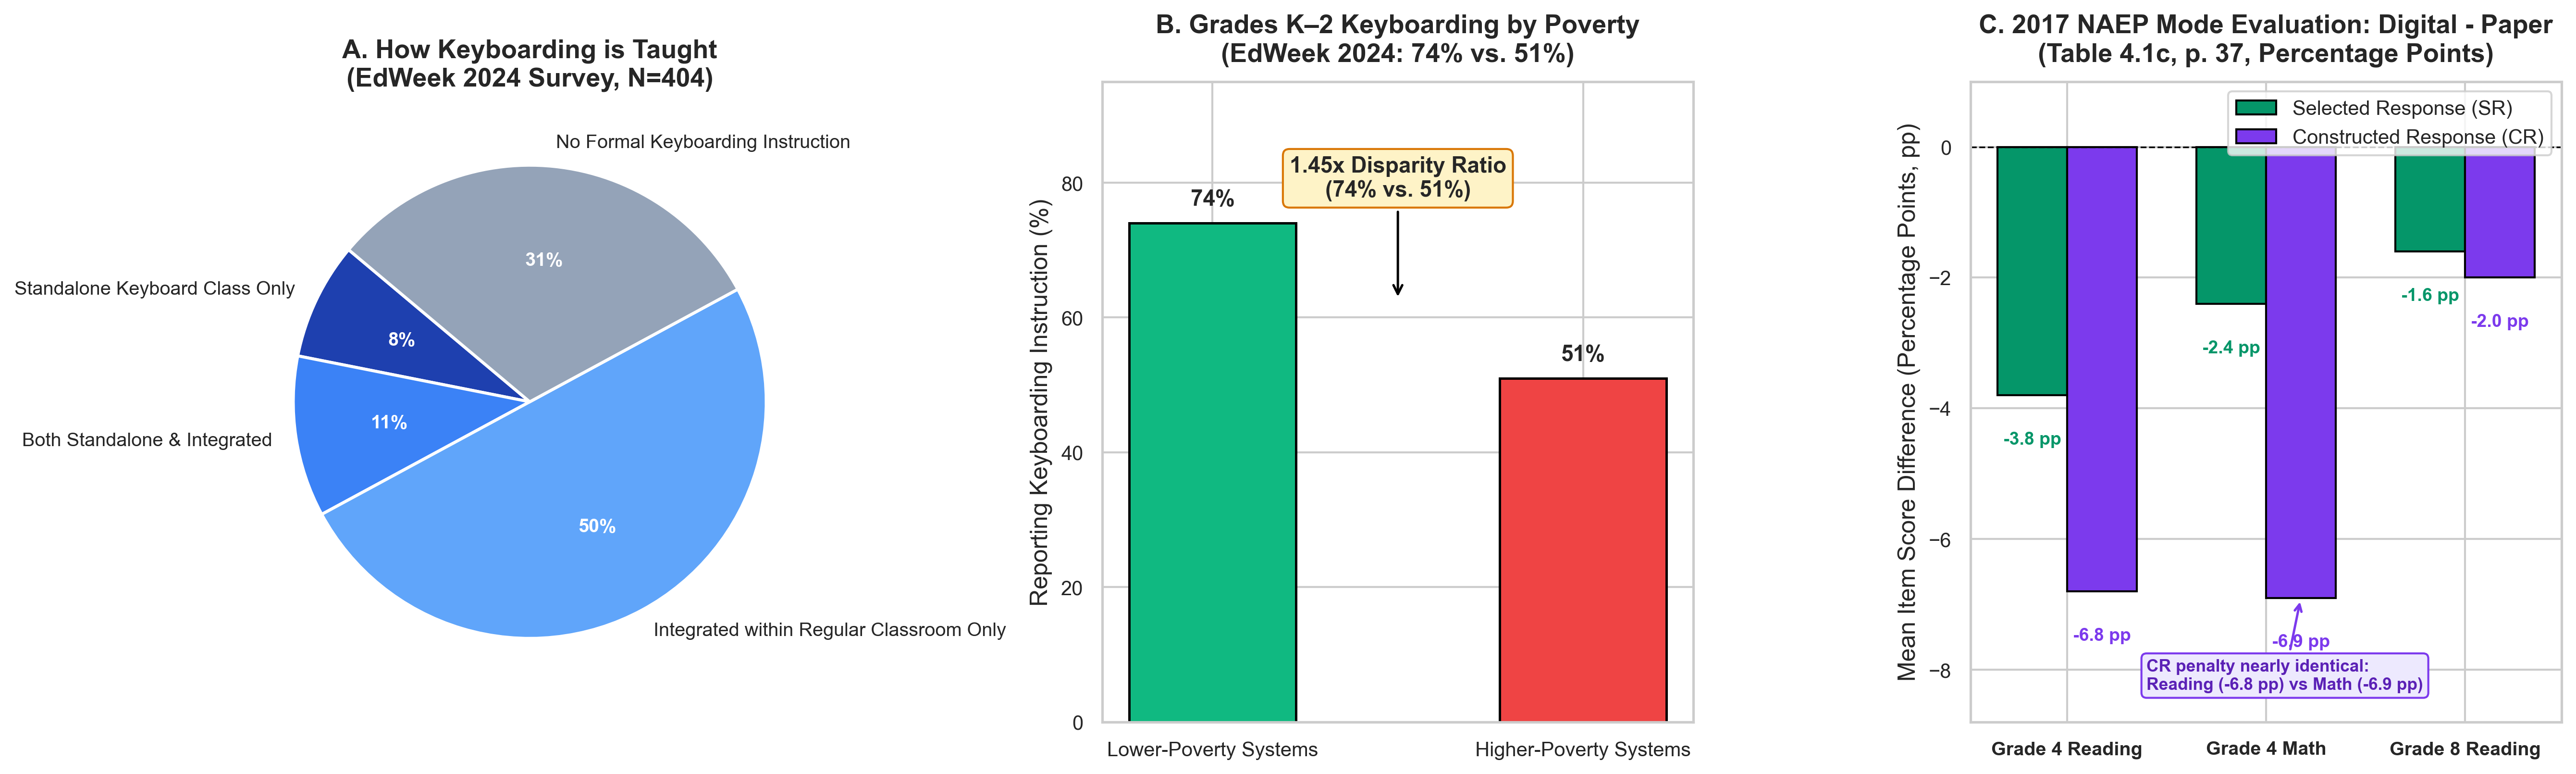

In [8]:
# Display Figure 3: Keyboarding Delivery & NAEP Table 4.1c
Image(filename=str(FIG_DIR / "fig3_naep_grade4_cr_penalty_and_teacher_expectations.png"))


## 6. Empirical Literature Synthesis: Reconciling Peer-Reviewed Evidence

We evaluate published empirical studies across state assessment transitions:
- **Massachusetts (Backes & Cowan 2019, *Economics of Education Review*, 68, 89–103)**:
  - Found an overall mode penalty of **$-0.25$ SD in ELA** and **$-0.10$ SD in math** in Year 1.
  - In Year 2, penalties attenuated to **$-0.13$ SD in ELA** and **$-0.05$ SD in math**, showing experiential learning.
- **South Carolina (Gordanier, Ozturk, & Zhan 2023, *Education Finance and Policy*, 18(2), 232–252, DOI: 10.1162/edfp_a_00373)**:
  - Statewide panel evaluating SC READY/PASS transitions in grades 3–8.
  - Estimated significant mode penalties of **$-0.085$ SD in ELA** and **$-0.044$ SD in Math**.
  - Negative impacts were significantly larger for students from low-income households, and were mitigated in schools with greater technology availability.
- **Tennessee Middle School Study (Parker 2018, *Journal of Research in Business Education*, 59(1), 1–14)**:
  - Analyzed $N = 916$ (Essay 1) and $N = 906$ (Essay 2) middle school students using chi-square tests of independence.
  - Found **no statistically significant relationship** ($p > 0.05$) between completing a 9-week keyboarding course and writing test proficiency.
  - *Methodological note*: A non-significant chi-square indicates a lack of detectable association in this quasi-experimental setting; it does not constitute proof of zero benefit nor a standardized effect size of 0.00 SD.
- **NAEP 2017 Writing Assessment Suppression**:
  - The National Assessment Governing Board (NAGB) declared the 2017 national writing assessment results **unreportable and suppressed**, citing severe comparability issues: typing speed constraints, 30–40% word count discrepancies, and tablet vs. laptop administration differences.


In [9]:
df_meta = pd.read_csv(TABLES_DIR / "table4_literature_benchmark.csv")
display(df_meta[["authors", "year", "publication", "jurisdiction", "subject", "reported_effect", "unit", "key_finding"]])


,authors,year,publication,jurisdiction,subject,reported_effect,unit,key_finding
0,Backes & Cowan,2019,"Economics of Education Review, Vol. 68, pp. 89...",Massachusetts (PARCC),ELA,-0.25 SD,Standard Deviations,Year 1 online penalty (-0.25 SD). Attenuated t...
1,Backes & Cowan,2019,"Economics of Education Review, Vol. 68, pp. 89...",Massachusetts (PARCC),Math,-0.10 SD,Standard Deviations,Year 1 online penalty (-0.10 SD). Attenuated t...
2,"Gordanier, Ozturk, & Zhan",2023,"Education Finance and Policy, Vol. 18(2), pp. ...",South Carolina (SC READY/PASS),ELA,-0.085 SD,Standard Deviations,Significant negative CBT impact in ELA; substa...
3,"Gordanier, Ozturk, & Zhan",2023,"Education Finance and Policy, Vol. 18(2), pp. ...",South Carolina (SC READY/PASS),Math,-0.044 SD,Standard Deviations,Significant negative CBT impact in Math (-0.04...
4,NCES / National Assessment Governing Board,2012,2012 NAEP Grade 4 Computer-Based Writing Pilot,National Representative Sample,Writing Response Length,"110 words (computer) vs. 159 words (paper, 2010)",Average Word Count / WPM,Computer responses were 31% shorter than paper...
5,Carol Parker,2018,Journal of Research in Business Education (NBE...,Tennessee Middle School,Writing Assessment,"Non-significant (Chi-square test, p > 0.05)",Qualitative / Chi-Square Independence,Did not detect a statistically significant ass...
6,National Assessment Governing Board (NAGB) / NCES,2017,2017 NAEP Writing Assessment Technical Summary,National Representative Sample,Writing Assessment Administration,UNREPORTABLE / SUPPRESSED,Administrative Action,Results suppressed due to severe comparability...


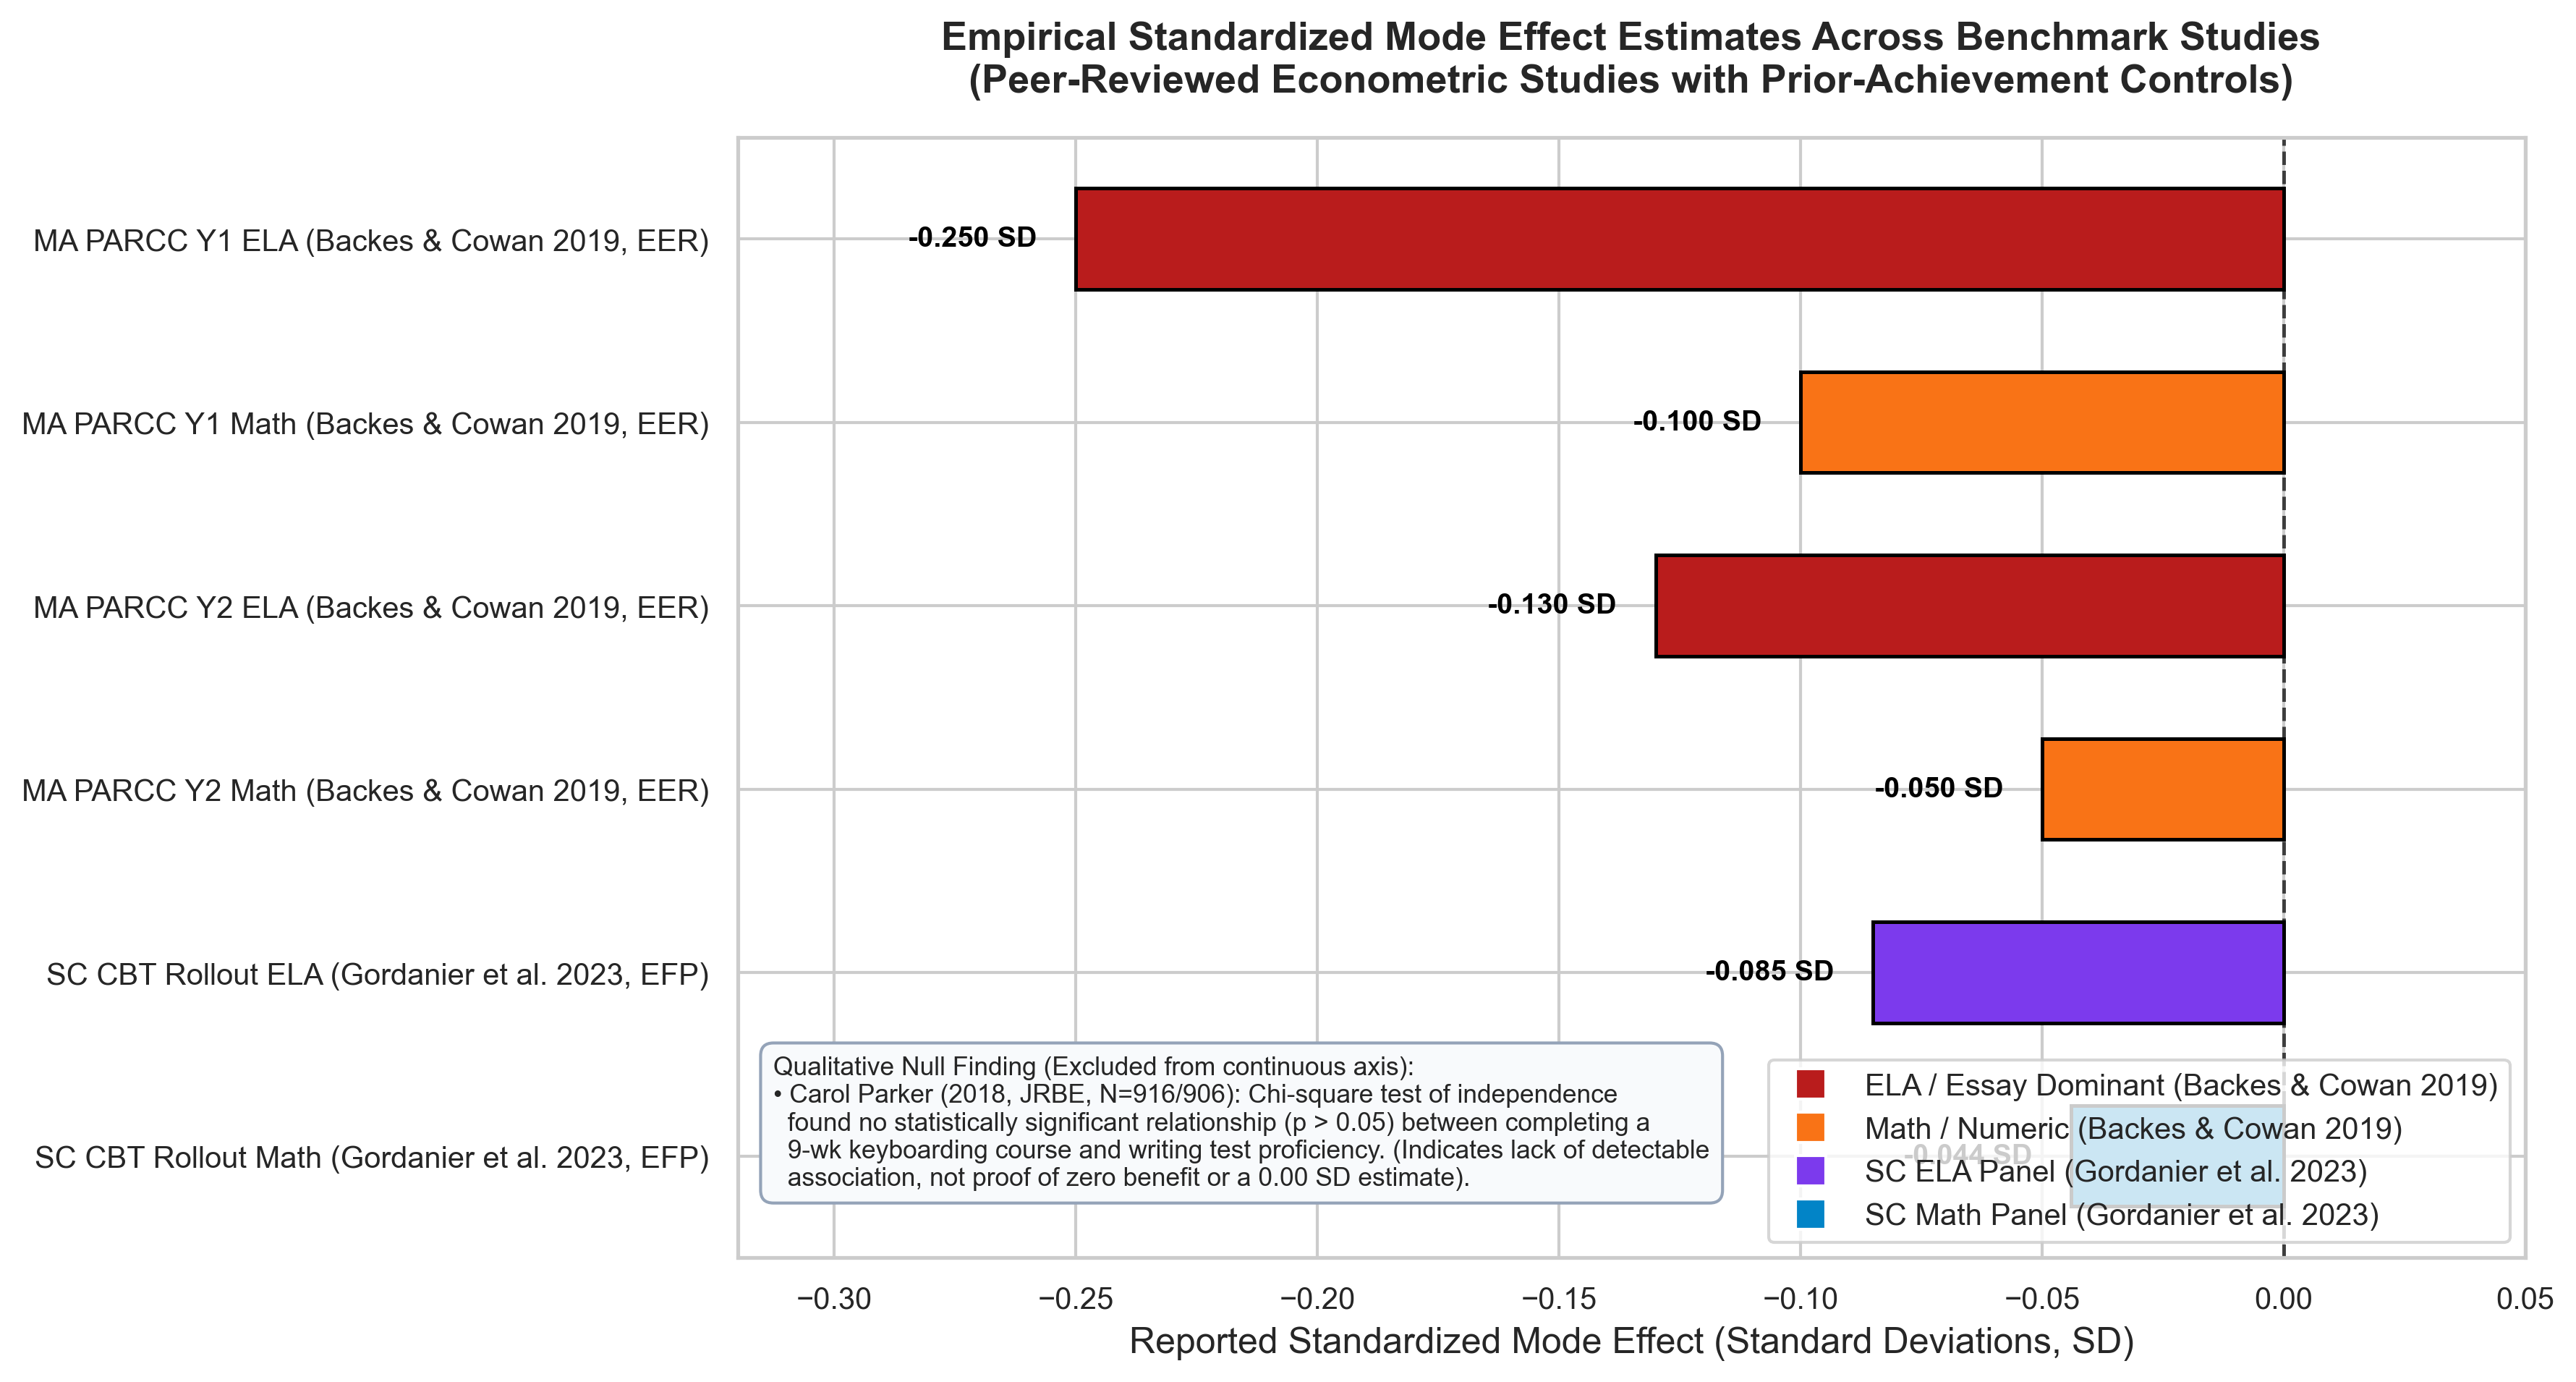

In [10]:
# Display Figure 2: Literature Mode Penalties
Image(filename=str(FIG_DIR / "fig2_mode_penalty_by_subject_and_format.png"))


## 7. Reconciling the Keyboarding Paradox: The "Simple View of Writing"

If digital testing introduces interface friction, why did Parker's (2018) Tennessee study find that a 9-week keyboarding course produced **no statistically significant writing improvement**?

### Cognitive Load & Threshold Mechanics
Psycholinguistic research (Berninger & Amtmann 1999; McCutchen 1996; Graham et al. 2007) models written expression as a hierarchical cognitive architecture:
1. **Transcription**: Keystroke mechanics, motor automaticity, spelling.
2. **Translation & Generation**: Formulating mental ideas into syntactic structures.
3. **Executive Planning & Review**: Coherence, argumentation, self-monitoring.

Transcription automaticity acts as a **threshold condition**, not a linear driver:
- Below $\approx 20-25$ Words Per Minute (WPM), typing requires conscious visual search ("hunt-and-peck"), draining working memory.
- Above $\approx 25$ WPM, transcription becomes automatic. Writing quality is then governed by vocabulary, reading comprehension, and content mastery.
- Isolated keyboarding drills that teach typing without integrating it into written composition do not automatically transfer to higher test scores.


## 8. Broader Digital Competence Erosion: The IEA ICILS Evidence

The interface deficit extends beyond typing speed to broader functional computer literacy:
- **IEA ICILS (International Computer and Information Literacy Study)**:
  - U.S. 8th graders scored **519** in 2018.
  - U.S. 8th graders dropped to **482** in 2023 ($-37$ points, $-0.37$ SD, $p < 0.001$).
  - **51%** scored at Level 1 or below (25% below Level 1 [deficient] + 26% at Level 1 [basic]).
  - **102-point socioeconomic gap** between students in the highest and lowest SES quartiles.


In [11]:
df_icils = pd.read_csv(RAW_DIR / "icils_cil_trends_2018_2023.csv")
display(df_icils)


,metric,year,score,se,sample_students,verification_status
0,U.S. 8th Grade CIL Score,2018,519.0,3.2,3200,Verified (NCES ICILS 2018)
1,U.S. 8th Grade CIL Score,2023,482.0,4.1,3600,Verified (NCES ICILS 2023)
2,Below Level 1 (Deficient),2023,25.0,1.2,3600,Verified (NCES ICILS 2023 Table)
3,Level 1 (Basic),2023,26.0,1.1,3600,Verified (NCES ICILS 2023 Table)
4,Combined At or Below Level 1,2023,51.0,1.5,3600,Verified (NCES ICILS 2023 Table)
5,Socioeconomic Gap (Highest vs Lowest SES Quart...,2023,102.0,6.8,3600,Verified (NCES ICILS 2023 Table)


## 9. Exploratory Parameter Sensitivity Analysis

Because student-level typing speed and score microdata are restricted, we evaluate an **exploratory parameter sensitivity analysis**:
$$f(\text{WPM}_i) = \beta_{\text{wpm}} \cdot \max(0, \tau - \text{WPM}_i)$$
We ground our speed distributions in the NCES 2012 Writing Usability benchmarks (Grade 4 mean = 12 WPM, SD = 5.0 WPM; Grade 8 mean = 30 WPM, SD = 8.0 WPM). We explore how simulated mean score penalties vary across hypothetical transcription thresholds ($\tau \in [15, 20, 25, 30]$ WPM) and penalty slopes ($\beta \in [-0.010, -0.018, -0.025]$).

*Crucial Epistemic Caveat*: This simulation illustrates theoretical model mechanics under hypothesized thresholds; it does **not** validate that typing fluency caused the observed testing gaps. Handwriting also imposes motor transcription burdens (fatigue, dysgraphia), and digital interfaces may offer benefits (editing flexibility, accommodations) for some students.


In [12]:
df_grid = pd.read_parquet(DATA_DIR / "typing_threshold_sensitivity_grid.parquet")
print("--- Parameter Sensitivity Grid (12 Scenarios Grounded in NCES Pilot Benchmarks) ---")
display(df_grid)


--- Parameter Sensitivity Grid (12 Scenarios Grounded in NCES Pilot Benchmarks) ---

,threshold_wpm,penalty_slope_sd_per_wpm,g4_pct_below_threshold,g4_mean_simulated_penalty_sd,g8_pct_below_threshold,g8_mean_simulated_penalty_sd,format_gap_simulated_sd
0,15,-0.010,67.5,-0.029,2.5,-0.001,-0.028
1,15,-0.018,67.5,-0.051,2.5,-0.002,-0.050
2,15,-0.025,67.5,-0.071,2.5,-0.002,-0.069
3,20,-0.010,93.7,-0.070,9.8,-0.004,-0.066
4,20,-0.018,93.7,-0.126,9.8,-0.007,-0.120
5,20,-0.025,93.7,-0.175,9.8,-0.009,-0.166
6,25,-0.010,99.7,-0.119,27.4,-0.012,-0.107
7,25,-0.018,99.7,-0.214,27.4,-0.022,-0.192
8,25,-0.025,99.7,-0.297,27.4,-0.031,-0.266
9,30,-0.010,99.9,-0.169,52.9,-0.032,-0.137


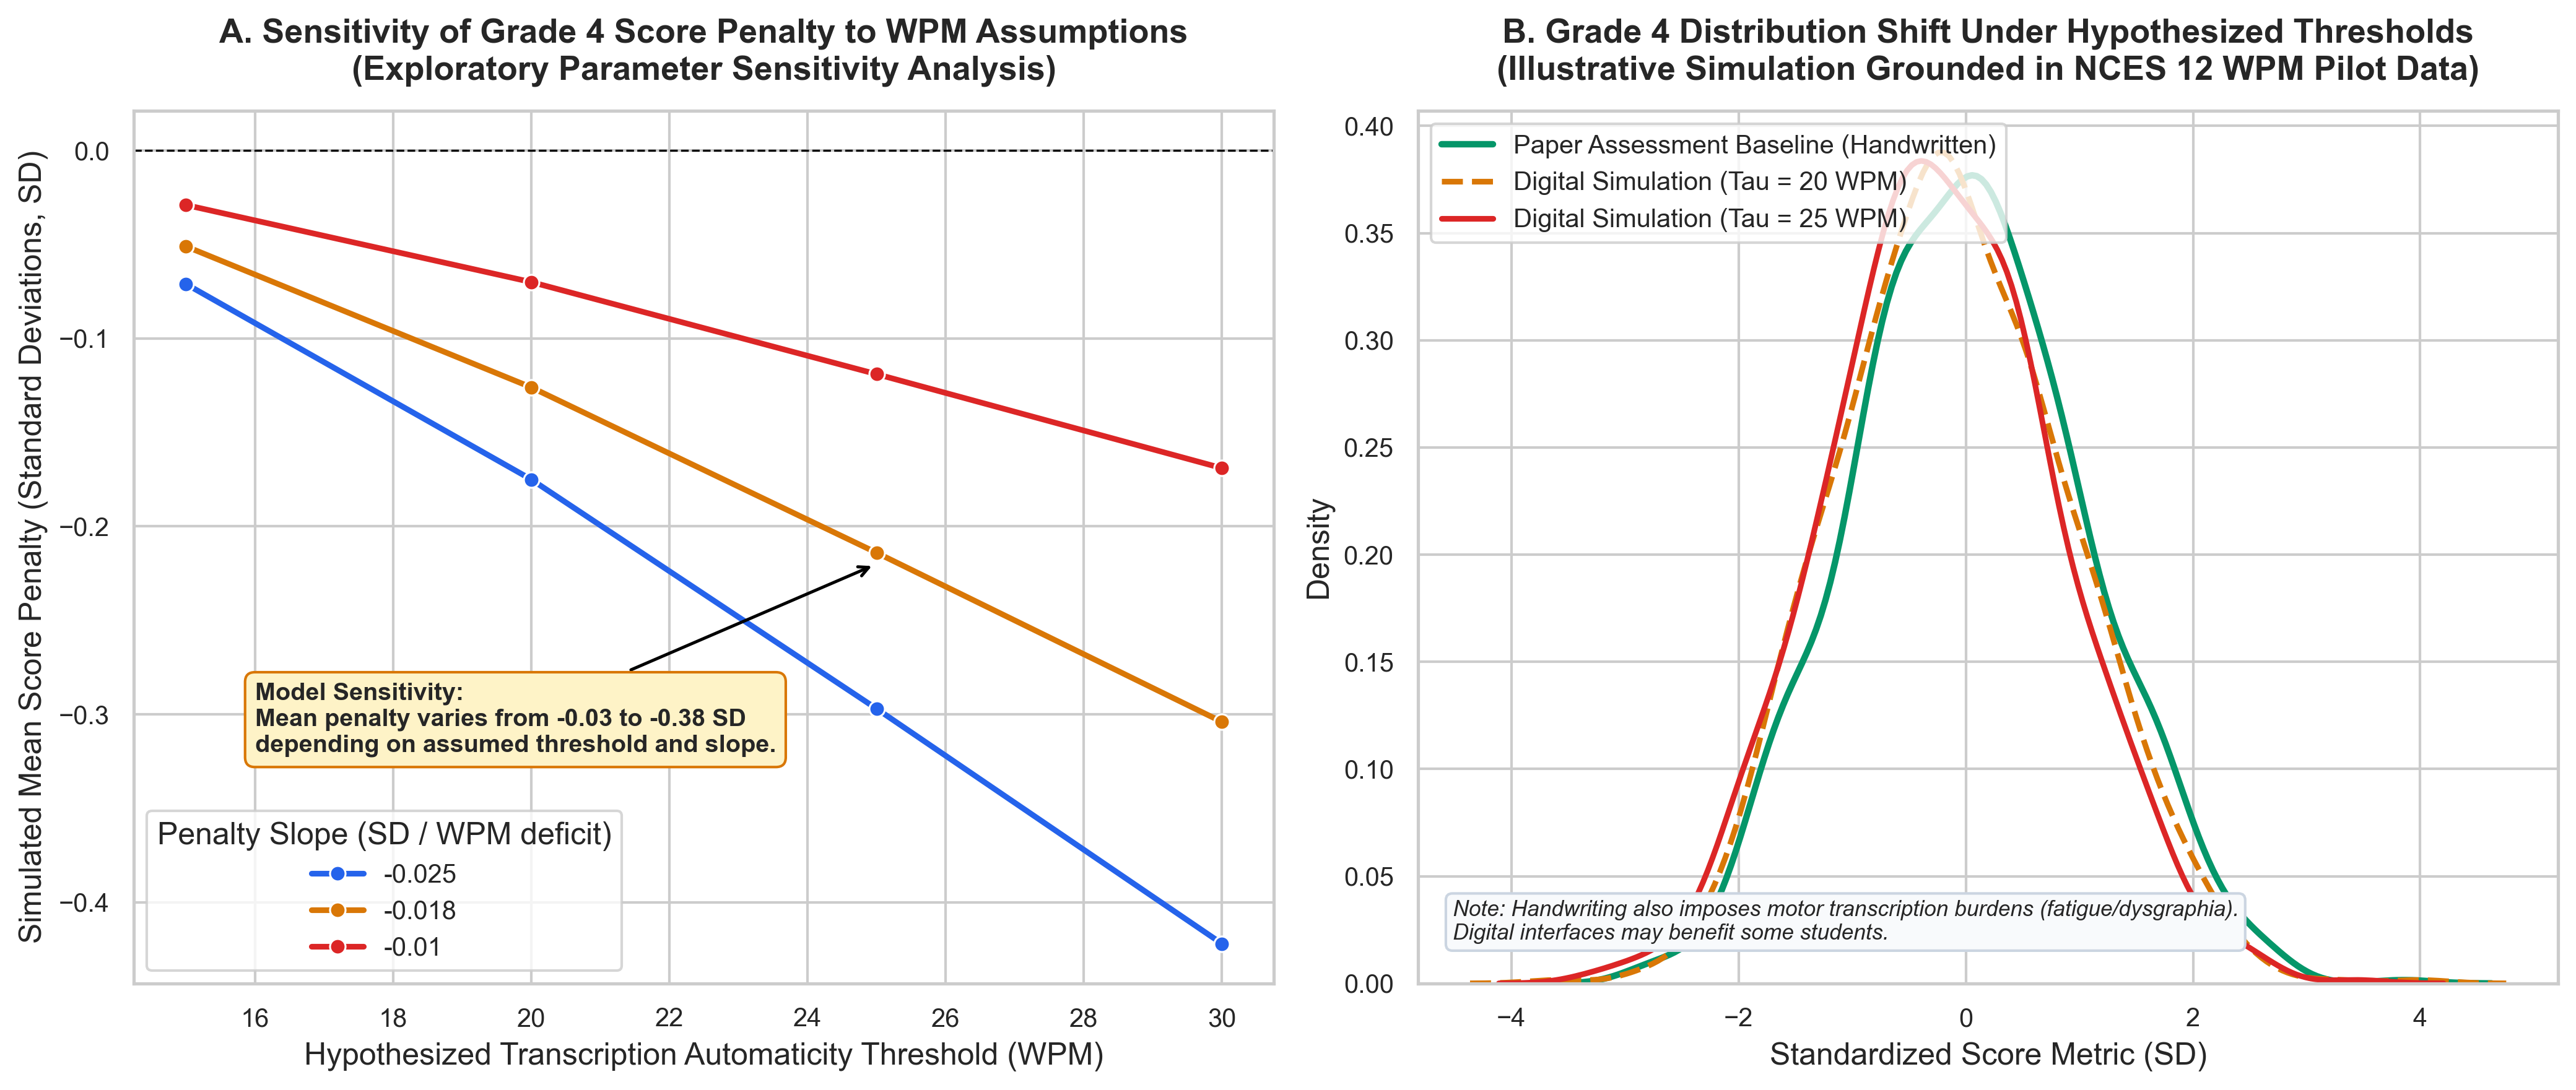

In [13]:
# Display Figure 4: Parameter Sensitivity Analysis
Image(filename=str(FIG_DIR / "fig4_psychometric_civ_simulation.png"))


## 10. Master Findings Scorecard & Proposed Experimental Research Agenda

### Synthesis of Core Questions

#### Question 1: Does digital assessment introduce an interface score penalty, especially on keyboard-intensive questions for younger students?
**YES. Empirical studies show that digital administration can depress measured student achievement, particularly on constructed-response items among younger students:**
1. **Massachusetts PARCC (Backes & Cowan 2019)**: An overall mode penalty of **$-0.25$ SD** in ELA and **$-0.10$ SD** in math in Year 1.
2. **South Carolina (Gordanier et al. 2023)**: Mode penalties of **$-0.085$ SD in ELA** and **$-0.044$ SD in Math**, larger for low-income students.
3. **NAEP 2017 Mode Evaluation (NCES Table 4.1c)**:
   - Grade 4 Reading: **$-3.8$ pp** on Selected Response vs. **$-6.8$ pp** on Constructed Response (a $-3.0$ pp format gap).
   - Grade 4 Mathematics: **$-2.4$ pp** on Selected Response vs. **$-6.9$ pp** on Constructed Response (a $-4.5$ pp format gap).
   - The constructed-response penalty in Math ($-6.9$ pp) matches Reading ($-6.8$ pp), pointing to a general digital response construction hurdle.
4. **Developmental Attenuation**: By Grade 8, the NAEP reading constructed-response penalty attenuates to **$-2.0$ pp** (format gap narrows to $-0.4$ pp).

#### Question 2: Did the national decline in standardized test scores get caused by declining keyboarding instruction?
**NO. Available evidence does NOT support this causal claim:**
1. **Statistical Equating**: NAEP explicitly implemented statistical linking in 2017 to remove mode differences from longitudinal score comparisons. Subsequent score declines between 2019 and 2024 occurred *within* an already digital testing baseline.
2. **Confounding Factors**: Post-2019 score declines coincided with massive pandemic disruptions, chronic absenteeism, and curriculum adjustments.
3. **The Keyboarding Null Result**: Parker's (2018) Tennessee middle school study found no statistically significant relationship ($p > 0.05$) between completing a 9-week keyboarding course and writing test proficiency.
4. **Universal Math Penalty**: The fact that Math constructed responses exhibit the exact same penalty as Reading indicates that interface friction is broader than keyboarding instruction alone.

---

## 11. Proposed Experimental Protocol: Isolating Keyboarding from Interface Noise

To separate typing fluency from reading navigation and cognitive item complexity, we propose a within-student randomized crossover trial:

```mermaid
flowchart TD
    S["Cohort of 4th & 5th Grade Students\n(Pre-tested for baseline WPM, touch typing, handwriting fluency, and reading ability)"]
    S --> R{"Random Assignment"}
    R -->|Group A| T1["Task 1: Prompt A on Paper (Handwritten)\nTask 2: Prompt B on Laptop (Digital Keyboard)"]
    R -->|Group B| T2["Task 1: Prompt A on Laptop (Digital Keyboard)\nTask 2: Prompt B on Paper (Handwritten)"]
    T1 --> M["Double-blind Scoring on Standardized Writing Rubric\n(Word Count, Syntactic Complexity, Text Structure)"]
    T2 --> M
    M --> E["Econometric Decomposition:\nEstimate marginal effect of WPM on Paper vs. Laptop score differential\nholding prompt difficulty and student latent ability constant"]
```

### Key Policy Recommendations
1. **Assessment Design**: State testing agencies should evaluate mode differences using item-level percentage-point tracking and ensure that young elementary students are not subjected to timed typing demands before transcription automaticity is established.
2. **Instructional Integration**: Schools should move away from isolated, siloed keyboarding drills and integrate touch-typing practice directly into daily classroom composition and digital literacy activities.
3. **Score Interpretation**: Accountability systems must account for mode effects when transitioning between assessment platforms.
